<a href="https://colab.research.google.com/github/aryanp2107/Deep_Learning/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

from sklearn.manifold import TSNE

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


What is an Autoencoder?

In [ ]:
"""
An autoencoder is a type of neural network that is trained to reconstruct its input data.
It learns to COMPRESS data and then DECOMPRESS it to get back the original input.

1. Encoder: It compress the input data into a smaller, more manageable form by reducing its dimensionality while preserving important information.
   It has three layers which are the input layer, hidden layers and the output

2. Bottleneck (Latent Space) - The bottleneck is the smallest layer in the network that holds a compressed representation of the input data.
   It forces the model to keep only the most important features, helping it learn key patterns and improve generalization.

3. Decoder - It is responsible for taking the compressed representation from the latent space and reconstructing it back into the original data form.
   It consists of three layers, the input layer, hidden layers and the output layer.

   Loss funstions in Autoencoder training:
   MSE, Binary Cross-entropy, Kullback-Leibler Divergence

  Key insight:
  • Bottleneck forces learning important features
  • Latent space = compressed representation
  • No labels needed! (Unsupervised)

Applications:
  • Dimensionality reduction
  • Denoising
  • Anomaly detection
  • Feature learning
  • Generation (VAE)

"""

In [8]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#normalizeing to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# flattening for the vanilla encoder
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

# Reshape for the CNN autoencoder
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print(f"Train: {x_train.shape}")
print(f"Test: {x_test.shape}")
print(f"Train Flat: {x_train_flat.shape}")
print(f"Test Flat: {x_test_flat.shape}")
print(f"Train CNN: {x_train_cnn.shape}")
print(f"Test CNN: {x_test_cnn.shape}")

Train: (60000, 28, 28)
Test: (10000, 28, 28)
Train Flat: (60000, 784)
Test Flat: (10000, 784)
Train CNN: (60000, 28, 28, 1)
Test CNN: (10000, 28, 28, 1)


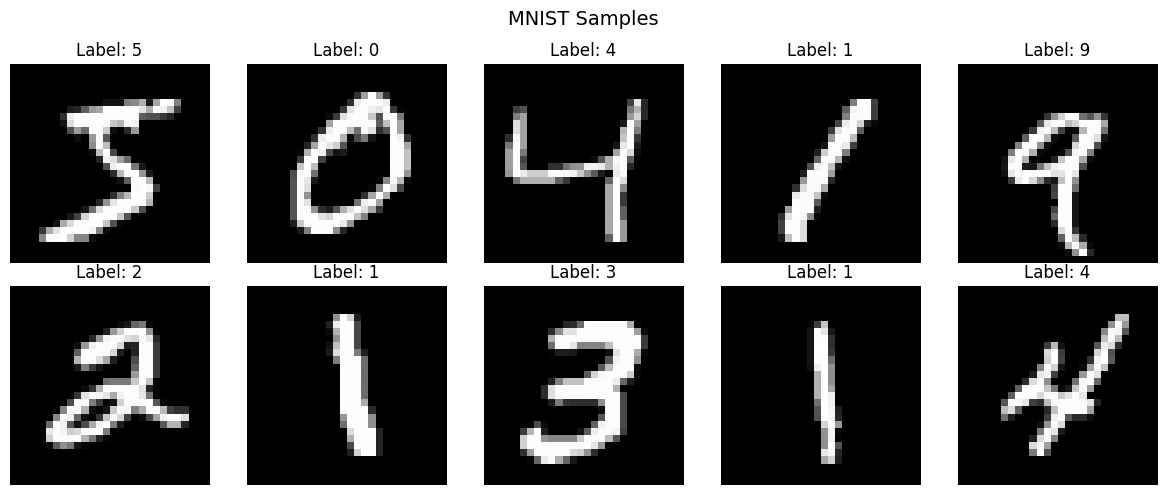

In [9]:
import matplotlib.pyplot as plt

# Visualize samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}')
    ax.axis('off')
plt.suptitle('MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
"""

Types of autoencoders:
Vanilla Autoencoder — The simplest form with a single hidden bottleneck layer; learns a compressed representation similar to PCA
                      but can capture nonlinear relationships.
Sparse Autoencoder — Adds a sparsity constraint (like L1 regularization or KL divergence) on the hidden activations,
                     forcing only a few neurons to activate at a time, which learns more meaningful and disentangled features.
Denoising Autoencoder (DAE) — Trained by corrupting the input (adding noise, masking pixels) and learning to reconstruct the clean original,
                              which forces the model to learn robust, generalizable features rather than memorizing identity.
Variational Autoencoder (VAE) — Instead of mapping to a fixed latent vector, it learns a probability distribution (mean and variance)
                                in latent space and samples from it, enabling smooth interpolation and generation of new data.
Contractive Autoencoder (CAE) — Adds a penalty on the Frobenius norm of the encoder's Jacobian matrix,
                                making the learned representation insensitive to small input perturbations and producing a more robust embedding.
Convolutional Autoencoder — Uses convolutional and transposed-convolutional layers instead of fully connected ones,
                            making it ideal for image data by preserving spatial structure during encoding and decoding.
Recurrent/LSTM Autoencoder — Uses recurrent layers (LSTM/GRU) as encoder and decoder,
                             designed for sequential data like time series or text where temporal dependencies matter.

"""

Vanilla Autoencoder

In [10]:
LATENT_DIM = 32

encoder_input = layers.Input(shape=(784,), name='encoder_input')
x = layers.Dense(256,  activation='relu')(encoder_input)
x =  layers.Dense(128, activation='relu')(x)
latent = layers.Dense(LATENT_DIM, activation ='relu', name='latent')(x)

encoder = models.Model(encoder_input, latent, name='encoder')

decoder_input = layers.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(128, activation='relu')(decoder_input)
x = layers.Dense(256, activation='relu')(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder = models.Model(decoder_input, decoder_output, name='decoder')

#full autoencoder
autoencoder_input = layers.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = models.Model(autoencoder_input, decoded, name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')

print(autoencoder.summary())

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       237,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       238,736 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
history_vanilla = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=20,
    batch_size=256,
    validation_data=(x_test_flat, x_test_flat),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0564 - val_loss: 0.0306
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0250 - val_loss: 0.0209
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0192 - val_loss: 0.0172
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0161 - val_loss: 0.0148
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0143 - val_loss: 0.0133
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0129 - val_loss: 0.0122
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0120 - val_loss: 0.0114
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0112 - val_loss: 0.0108
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0107 - val_loss: 0.0105
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0102 - val_loss: 0.0099
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0099 - val_loss: 0.0096
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

<Figure size 640x480 with 0 Axes>

Vanilla Autoencoder:


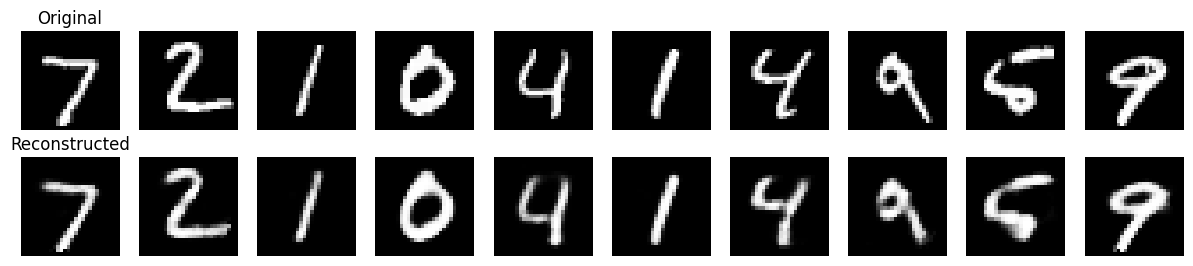

In [13]:
#Visualizing the reconstructions
def plot_reconstructions(model, x_test, n=10):
  reconstructed = model.predict(x_test[:n], verbose=0)

  fig, axes = plt.subplots(2, n, figsize=(15, 3))
  for i in range(n):
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
      axes[0, i].set_title('Original')
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
      axes[1, i].set_title('Reconstructed')

plt.tight_layout()
plt.show()

print("Vanilla Autoencoder:")
plot_reconstructions(autoencoder, x_test_flat)

Visualizing the latent space

In [14]:
# Encode test set
latent_vectors = encoder.predict(x_test_flat, verbose=0)
print(f"Latent vectors shape: {latent_vectors.shape}")

# t-SNE visualization
print("Running t-SNE...")
n_samples = 5000
indices = np.random.choice(len(latent_vectors), n_samples, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_vectors[indices])
print("Done!")

Latent vectors shape: (10000, 32)
Running t-SNE...
Done!


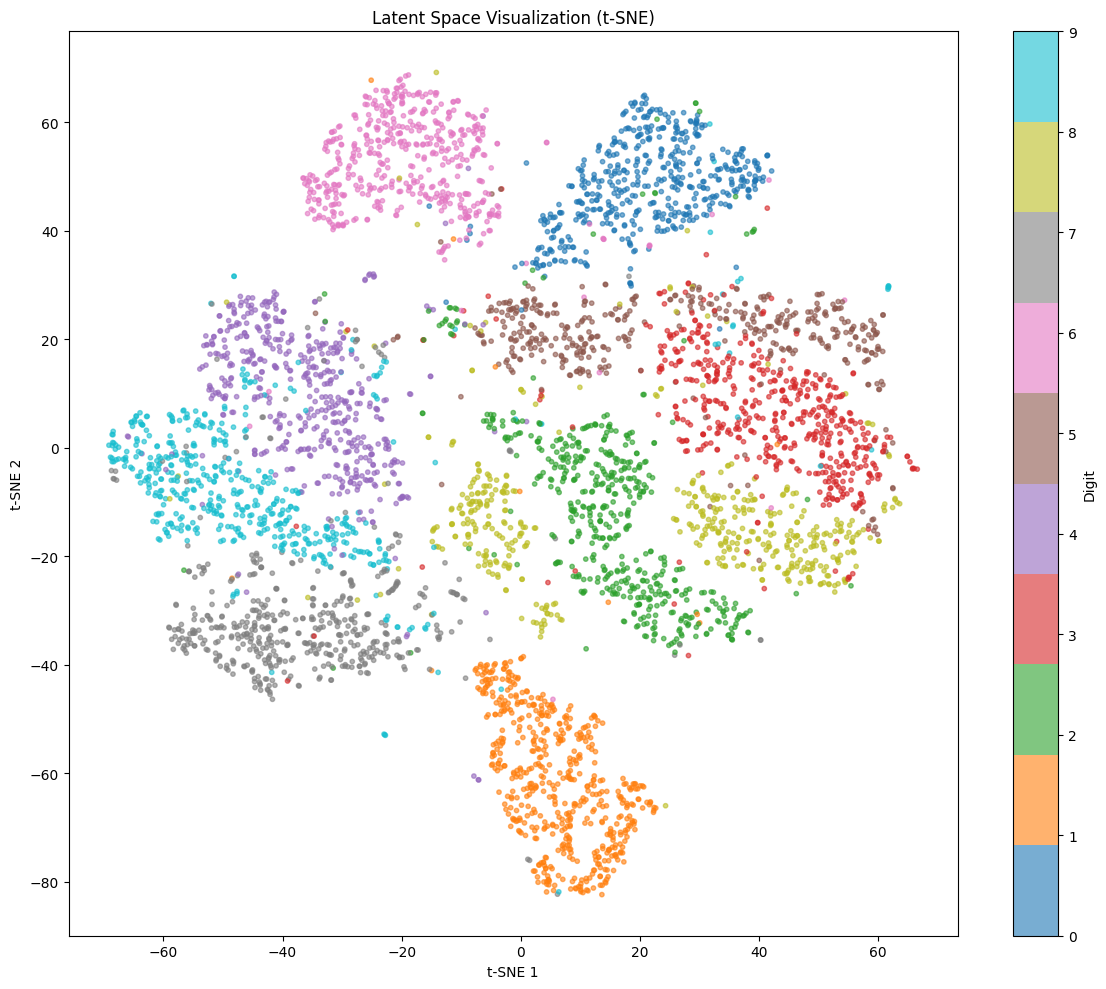

In [15]:
# Plot latent space
plt.figure(figsize=(12, 10))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test[indices], cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Digit')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Latent Space Visualization (t-SNE)')
plt.tight_layout()
plt.show()

Convolutional Autoencoder (Works better for images)

In [19]:
cnn_encoder_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(cnn_encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
cnn_encoded = layers.Flatten()(x)
cnn_latent = layers.Dense(LATENT_DIM, activation='relu', name='cnn_latent')(cnn_encoded)

cnn_encoder = models.Model(cnn_encoder_input, cnn_latent, name='cnn_encoder')

#DECODER
cnn_decoder_input = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(7 * 7 * 128, activation='relu')(cnn_decoder_input)
x = layers.Reshape((7, 7, 128))(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x)  #14x14
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x)  #28x28
cnn_decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

cnn_decoder = models.Model(cnn_decoder_input, cnn_decoder_output, name='cnn_decoder')

#Full model
cnn_ae_input = layers.Input(shape=(28, 28, 1))
cnn_autoencoder = models.Model(cnn_ae_input, cnn_decoder(cnn_encoder(cnn_ae_input)), name='cnn_ae')
cnn_autoencoder.compile(optimizer='adam', loss='mse')

print(cnn_autoencoder.summary())

Model: "cnn_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_encoder (Functional)        │ (None, 32)             │       293,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_decoder (Functional)        │ (None, 28, 28, 1)      │       299,521 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,929 (2.26 MB)

 Trainable params: 592,929 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [20]:
history_cnn = cnn_autoencoder.fit(
    x_train_cnn, x_train_cnn,
    epochs=20,
    batch_size=256,
    validation_data=(x_test_cnn, x_test_cnn),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - loss: 0.0564 - val_loss: 0.0242
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0175 - val_loss: 0.0136
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0123 - val_loss: 0.0107
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0100 - val_loss: 0.0092
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0088 - val_loss: 0.0083
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0080 - val_loss: 0.0076
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0074 - val_loss: 0.0071
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0063 - val_loss: 0.0063
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

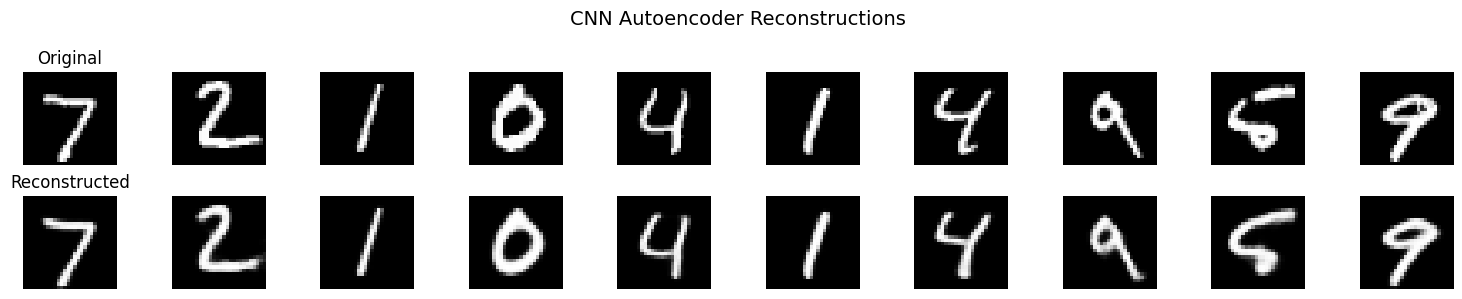


Vanilla AE val loss: 0.008071
CNN AE val loss: 0.005598
Convolutional Autoencoder:


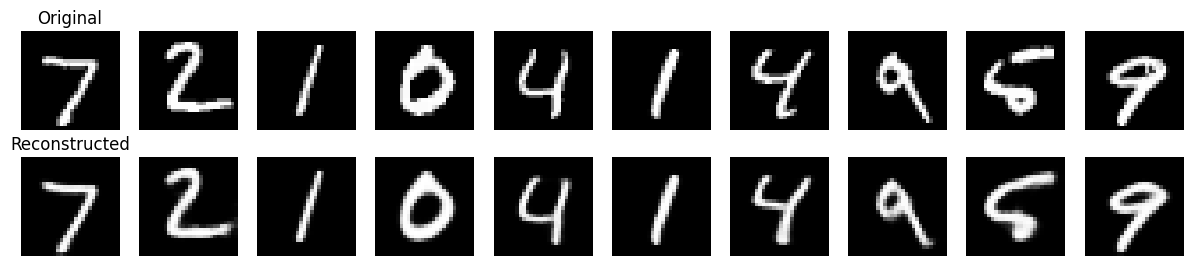

In [22]:
# Visualize CNN reconstructions
cnn_reconstructed = cnn_autoencoder.predict(x_test_cnn[:10], verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    axes[1, i].imshow(cnn_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Reconstructed')

plt.suptitle('CNN Autoencoder Reconstructions', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nVanilla AE val loss: {history_vanilla.history['val_loss'][-1]:.6f}")
print(f"CNN AE val loss: {history_cnn.history['val_loss'][-1]:.6f}")

print("Convolutional Autoencoder:")
plot_reconstructions(cnn_autoencoder, x_test_cnn)

Denoising Autoencoder: train on noisy input -> ereconstruct CLEAN output

In [34]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

In [35]:
"""
Noisy Image → ENCODER → Latent → DECODER → Clean Image

"""
#Adding noise
noise_factor = 0.5
x_train_noisy = x_train_cnn + noise_factor * np.random.normal(size=x_train_cnn.shape)
x_test_noisy = x_test_cnn + noise_factor * np.random.normal(size=x_test_cnn.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

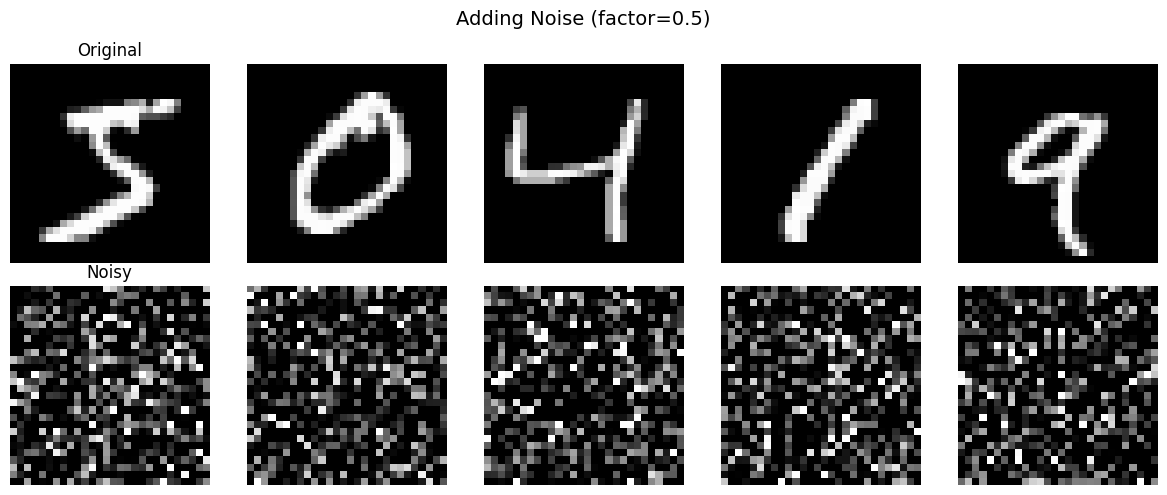

In [36]:
# Visualize
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(x_train_cnn[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    axes[1, i].imshow(x_train_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Noisy')

plt.suptitle(f'Adding Noise (factor={noise_factor})', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Denoising Autoencoder
denoise_input = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(denoise_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(x)
denoise_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

denoising_ae = models.Model(denoise_input, denoise_output, name='denoising_ae')
denoising_ae.compile(optimizer='adam', loss='mse')

# Train on noisy input, clean target
print("Training Denoising Autoencoder...")
history_denoise = denoising_ae.fit(
    x_train_noisy, x_train_cnn,
    epochs=20,
    batch_size=256,
    validation_data=(x_test_noisy, x_test_cnn),
    verbose=1
)


Training Denoising Autoencoder...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0075 - val_loss: 2.8317e-06
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.5077e-06 - val_loss: 2.2754e-06
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 2.0801e-06 - val_loss: 1.9783e-06
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.8793e-06 - val_loss: 1.8563e-06
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.7994e-06 - val_loss: 1.8077e-06
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7661e-06 - val_loss: 1.7860e-06
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7503e-06 - val_loss: 1.7749e-06
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 1.7417e-06 - val_loss: 1.7686e-06
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 1.7366e-06 - val_loss: 1.7646e-06
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 1.7334e-06 - val_loss: 1.7620e-06
Epoch 11/20
235/235

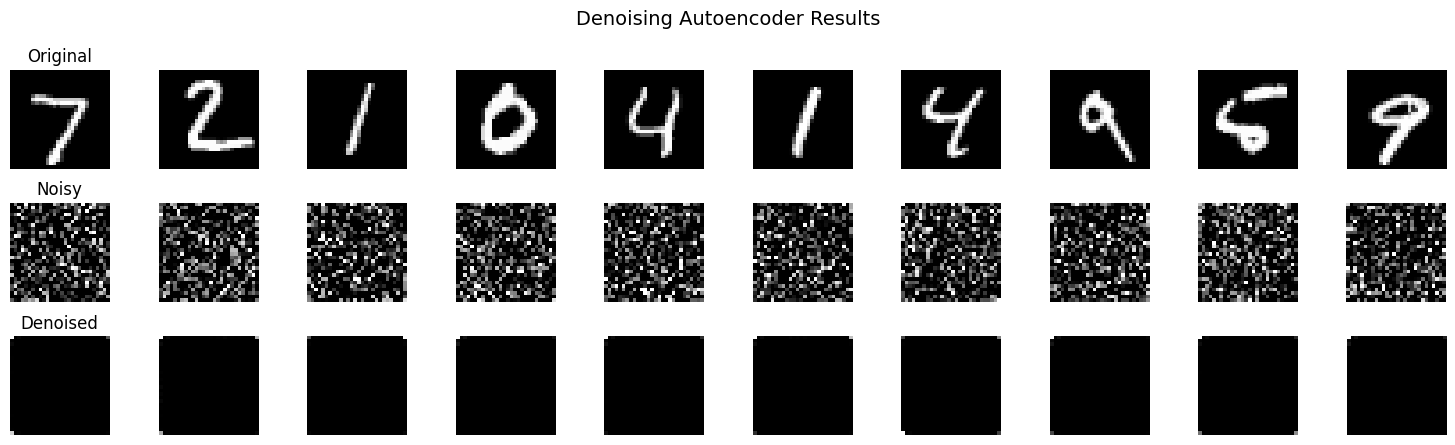

In [38]:
# Visualize denoising
denoised = denoising_ae.predict(x_test_noisy[:10], verbose=0)

fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for i in range(10):
    axes[0, i].imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original')

    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Noisy')

    axes[2, i].imshow(denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title('Denoised')

plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

Sparse Autoencoder: Add sparsity constraint to latent representation (forces neurons to specialize - L1 regularization)

In [42]:
SPARSITY = 1e-5

sparse_input = layers.Input(shape=(784,))
x = layers.Dense(256, activation='relu')(sparse_input)
x = layers.Dense(128, activation='relu')(x)
sparse_latent = layers.Dense(LATENT_DIM, activation='relu', activity_regularizer=regularizers.l1(SPARSITY))(x)
x = layers.Dense(128, activation='relu')(sparse_input)
x = layers.Dense(256, activation='relu')(x)
sparse_output = layers.Dense(784, activation='sigmoid')(x)

sparse_autoencoder = models.Model(sparse_input, sparse_output, name='sparse_autoencoder')
sparse_autoencoder.compile(optimizer='adam', loss='mse')

print(sparse_autoencoder.summary())

Model: "sparse_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,992 (1.28 MB)

 Trainable params: 334,992 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

None


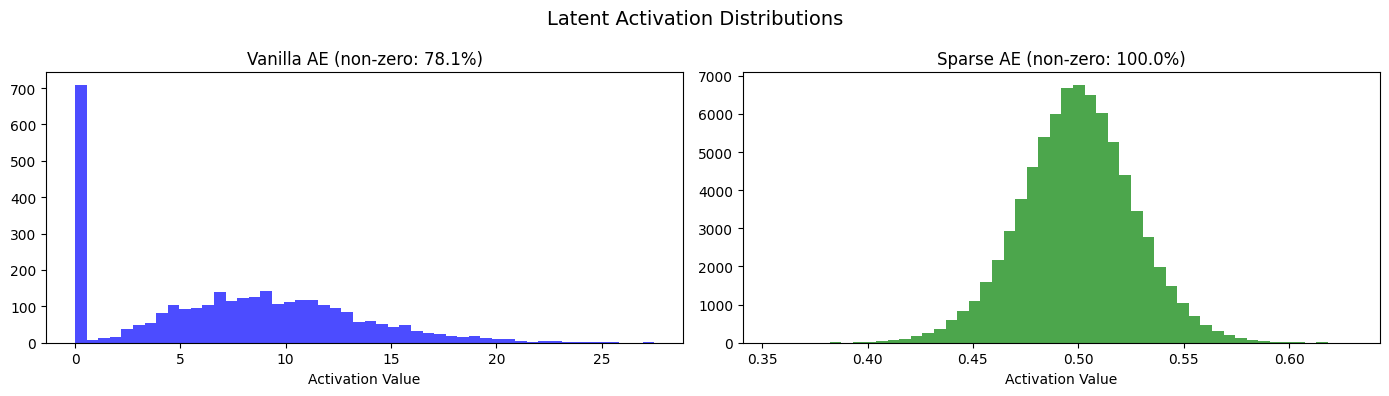

In [44]:
# Compare sparsity
vanilla_latent = encoder.predict(x_test_flat[:100], verbose=0)
sparse_latent_vals = sparse_autoencoder.predict(x_test_flat[:100], verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(vanilla_latent.flatten(), bins=50, alpha=0.7, color='blue')
axes[0].set_title(f'Vanilla AE (non-zero: {(vanilla_latent > 0.01).mean():.1%})')
axes[0].set_xlabel('Activation Value')

axes[1].hist(sparse_latent_vals.flatten(), bins=50, alpha=0.7, color='green')
axes[1].set_title(f'Sparse AE (non-zero: {(sparse_latent_vals > 0.01).mean():.1%})')
axes[1].set_xlabel('Activation Value')

plt.suptitle('Latent Activation Distributions', fontsize=14)
plt.tight_layout()
plt.show()

Anomaly Detection

In [45]:
# Train on digit 1 only (normal)
digit_1_train = x_train_flat[y_train == 1]
digit_1_test = x_test_flat[y_test == 1]
anomaly_test = x_test_flat[y_test != 1][:len(digit_1_test)]

print(f"Normal train: {digit_1_train.shape}")
print(f"Anomaly test: {anomaly_test.shape}")

Normal train: (6742, 784)
Anomaly test: (1135, 784)


In [46]:
# Build and train
anomaly_ae = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid')
])
anomaly_ae.compile(optimizer='adam', loss='mse')

print("Training on NORMAL data only...")
anomaly_ae.fit(digit_1_train, digit_1_train, epochs=20, batch_size=256, validation_split=0.1, verbose=1)

Training on NORMAL data only...
Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 0.1352 - val_loss: 0.0292
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0273 - val_loss: 0.0208
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0198 - val_loss: 0.0163
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0170 - val_loss: 0.0147
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0156 - val_loss: 0.0138
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0148 - val_loss: 0.0133
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0142 - val_loss: 0.0127
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 - val_loss: 0.0115
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0085
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - val_loss: 0.0075
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0

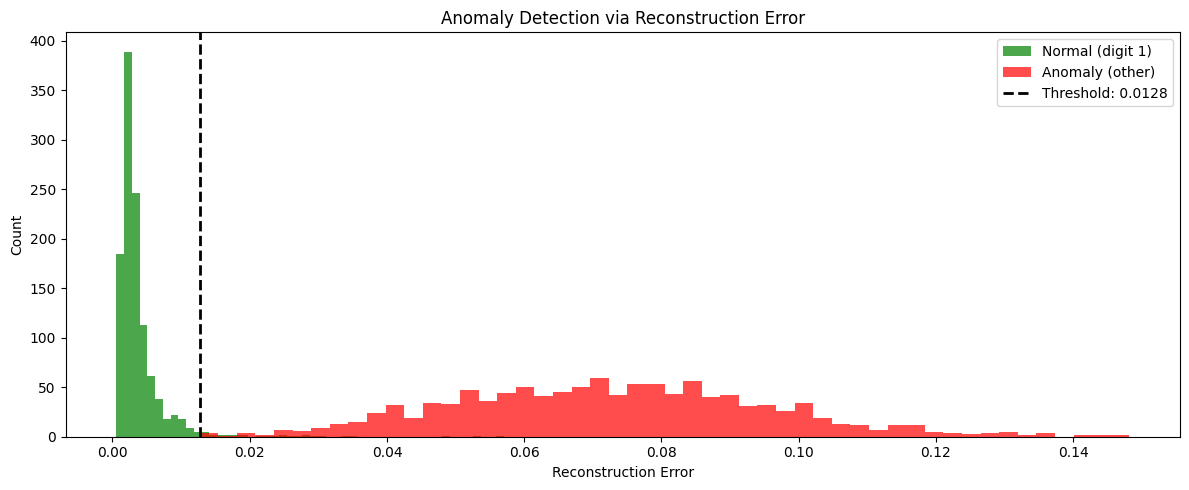


Anomaly detection rate: 99.9%


In [47]:
# Compute reconstruction errors
normal_pred = anomaly_ae.predict(digit_1_test, verbose=0)
anomaly_pred = anomaly_ae.predict(anomaly_test, verbose=0)

normal_errors = np.mean((digit_1_test - normal_pred) ** 2, axis=1)
anomaly_errors = np.mean((anomaly_test - anomaly_pred) ** 2, axis=1)

# Plot
plt.figure(figsize=(12, 5))
plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal (digit 1)', color='green')
plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly (other)', color='red')

threshold = normal_errors.mean() + 2 * normal_errors.std()
plt.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')

plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Anomaly Detection via Reconstruction Error')
plt.legend()
plt.tight_layout()
plt.show()

# Detection rate
detected = (anomaly_errors > threshold).mean()
print(f"\nAnomaly detection rate: {detected:.1%}")

In [48]:
import os
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-56-autoencoders'
os.makedirs(save_path, exist_ok=True)

autoencoder.save(f'{save_path}/vanilla_ae.keras')
cnn_autoencoder.save(f'{save_path}/cnn_ae.keras')
denoising_ae.save(f'{save_path}/denoising_ae.keras')

print(f"\nSaved to: {save_path}")

Mounted at /content/drive

Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-56-autoencoders
